### Langchain version v1

In [2]:
import langchain
print(langchain.__version__)

1.3.1


In [3]:
import os
from dotenv import load_dotenv

In [4]:
load_dotenv()
gemini = os.getenv("GEMINI_API_KEY")
Groq_API_Key = os.getenv("GROQ_API_KEY")

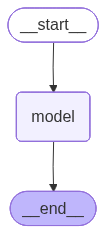

In [5]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

llm = init_chat_model(
    model="gemini-2.0-flash",
    model_provider="google_genai"
)

agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="You are a senior software engineer"
)

agent

## Adding a tool with agent

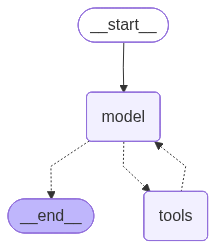

In [45]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from datetime import datetime

llm = init_chat_model(
    model = "google_genai:gemini-2.5-flash",
    # model_provider = "google_genai"
)

# Tool 1
def get_current_time(time:str)->str:
    """This is retuning current time Jeddah"""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Tool 2
def get_weather(city:str)->str:
    """This is retuning current weather of a city"""
    return "The current weather in {} is sunny"


agent = create_agent(
    model = "google_genai:gemini-2.5-flash",
    tools = [get_current_time, get_weather],
    system_prompt = "You are a senior software engineer"
)
agent

In [30]:
response = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "What is the current time of Jeddah"
        }]
    })

# We can avoid roles and directly pass the query to the agent
# response = agent.invoke("What is the current time of Jeddah")

In [42]:
query = response["messages"][0].content
output = response["messages"][-1].content
print(f"For the query: {query}, the agent responded with: {output}")

For the query: What is the current time of Jeddah, the agent responded with: The current time in Jeddah is 04:02:26 on 2026-06-03.


# Model Integration with GEMINI and GROQ

## Gemini Integration

In [49]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model = "google_genai:gemini-2.5-flash"
)
response = model.invoke("What is langsmith?")
response.content

"**LangSmith** is a platform developed by LangChain, designed to help developers **monitor, debug, test, and evaluate** their Large Language Model (LLM) applications throughout their entire lifecycle.\n\nIn essence, if you're building applications powered by LLMs (especially complex ones involving multiple steps, tools, and chains like those built with the LangChain framework), LangSmith acts as your control center to understand, improve, and ensure the reliability of your AI system.\n\nHere's a breakdown of its key functionalities and why it's needed:\n\n### Why is LangSmith Needed? (The Problem it Solves)\n\nDeveloping LLM applications is challenging because:\n1.  **Non-deterministic:** LLMs can produce different outputs for the same input, making debugging hard.\n2.  **Complex Chains:** Applications often involve multiple LLM calls, tool uses, and custom logic (chains, agents), making it difficult to trace execution flow.\n3.  **Hard to Debug:** Traditional debugging tools aren't we

We can also use their dedicated libraries, used in large and complex scope problems

In [50]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash"
)
response = model.invoke("In few lines, what is langsmith?")
response.content

"Langsmith is a platform that helps developers build, evaluate, and monitor Large Language Model (LLM) applications.\n\nIt provides tools for:\n*   **Debugging** complex LLM chains and understanding their internal workings.\n*   **Testing and evaluating** different prompts, models, and configurations.\n*   **Monitoring** the performance and behavior of LLM applications in production.\n\nEssentially, it's an end-to-end platform for improving the reliability and performance of LLM-powered systems."

## GROQ Model Integration

1- Use init_chat_model  
2- Use Groq Library

In [6]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="groq:qwen/qwen3-32b",
    reasoning_effort="none"
)
response = model.invoke("Like langsmith, is there any framework for computer vision?")
response.content

"Yes, just like **LangSmith** for **large language models (LLMs)** and **natural language processing (NLP)**, there are several frameworks specifically designed for **computer vision** (CV) tasks. These frameworks provide tools for data processing, model training, evaluation, deployment, and monitoring in computer vision workflows.\n\nHere are some **popular computer vision frameworks** and **toolkits** that play a role similar to **LangSmith**, depending on what aspect you're interested in (experiment tracking, model building, deployment, etc.):\n\n---\n\n### 🔧 **1. MMDetection (MMDet)**\n- **Description**: A detection toolbox developed by the [OpenMMLab](https://openmmlab.com/) for object detection tasks.\n- **Features**:\n  - Supports multiple detection models: Faster R-CNN, YOLO, SSD, etc.\n  - Easy to train custom models on your datasets.\n  - Comes with pre-trained models and benchmarking tools.\n- **Website**: [https://github.com/open-mmlab/mmdetection](https://github.com/open-m

In [57]:
from langchain_groq import ChatGroq
model = ChatGroq(
    model="qwen/qwen3-32b",
    # api_key=Groq_API_Key,
    reasoning_effort="none"
)
response = model.invoke("In few words,Like langsmith, is there any framework for computer vision?")
response.content

"Yes, there are several frameworks for computer vision similar to **LangSmith** (which is for LLM development), though they serve different purposes. Here are a few notable ones:\n\n### 1. **Label Studio** (https://label-studio.io)\n- Open-source, supports **computer vision**, NLP, audio, video, etc.\n- Great for **data labeling, annotation, and workflow management**.\n- Integrates with models and tools.\n\n### 2. **CVAT** (https://opencv.org/cvat/)\n- **Computer Vision Annotation Tool** by OpenCV.\n- Designed for **video and image annotation**.\n- Used in production for object detection, segmentation, etc.\n\n### 3. **VGG Image Annotator (VIA)** (https://www.robots.ox.ac.uk/~vgg/software/via/)\n- Web-based, lightweight.\n- Simple and good for **manual image annotation**.\n- No setup required.\n\n### 4. **SuperAnnotate** (https://www.superannotate.com)\n- Commercial tool with **automated annotation** and ML integration.\n- Good for **teams needing collaboration and model training**.\n\

## Streaming
To avaoid waiting for complete output to be displayed, we can use stream to simultaneous print generated output

In [58]:
model.stream("In few lines, Why do cats meow?")

<generator object BaseChatModel.stream at 0x7076ba22aec0>

In [60]:
#To display it, we will use loop
for chunk in model.stream("In few lines, Why do cats meow?"):
    print(chunk.content, end="|", flush=True)

|C|ats| me|ow| primarily| to| communicate| with| humans|,| as| adult| cats| rarely| me|ow| at| each| other|.| They| use| me|owing| to| express| needs|,| desires|,| greetings|,| or| discomfort|,| making| it| a| versatile| vocal| tool| in| their| interaction| with| people|.|||

## Batch
To reduce api cost and enhance performance, batch allow us to pass mulitple prompts togeather

In [63]:
responses = model.batch([
    "Briefly tell about  quantum computing",
    "What is the capital of France?"
])
# responses
for response in responses:
    print(response.content, end="\n")

Quantum computing is a type of computing that uses **quantum bits (qubits)**, which can exist in multiple states simultaneously due to the principles of **superposition** and **entanglement**. Unlike classical computers that use bits (0 or 1), quantum computers can process complex calculations exponentially faster for certain problems, such as:

- **Factorizing large numbers** (important for cryptography),  
- **Simulating quantum systems** (useful in chemistry and materials science),  
- **Optimization problems** in logistics, finance, and machine learning.

Quantum computing is still in early stages, with challenges like **qubit stability** and **error correction**, but it holds transformative potential for fields like drug discovery, AI, and secure communications. Major companies like IBM, Google, and startups are actively developing quantum technologies.
The capital of France is Paris.


In [64]:
# we can limit the parallel requests by passing the parameter `max_concurrent_requests`
responses = model.batch(
    [
        "Briefly tell about  quantum computing",
        "What is the capital of France?"
    ],
    config={"max_concurrent_requests": 3}
)
# responses
for response in responses:
    print(response.content, end="\n\n")

Quantum computing is a type of computing that uses quantum-mechanical phenomena, such as superposition and entanglement, to perform operations on data. Unlike classical computers, which use bits as their smallest unit of data (either 0 or 1), quantum computers use **qubits** (quantum bits), which can exist in **superpositions** of both 0 and 1 simultaneously.

This allows quantum computers to process vast amounts of information in parallel, making them potentially much faster than classical computers for specific tasks, such as:

- Factoring large numbers (important for cryptography)
- Simulating quantum systems (useful in chemistry and materials science)
- Solving optimization problems
- Machine learning and data analysis

Key quantum concepts include:

- **Superposition**: A qubit can be in multiple states at once.
- **Entanglement**: Qubits can be linked so that the state of one instantly affects the state of another, no matter the distance.
- **Quantum Interference**: Used to ampli

## Tools

In [14]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather of a location"""
    return f"The weather in {location} is sunny."

model_with_tool = model.bind_tools([get_weather])
response = model_with_tool.invoke("What is the weather in Jeddah?")
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bm3ntgnjg', 'function': {'arguments': '{"location":"Jeddah"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 159, 'total_tokens': 181, 'completion_time': 0.027636897, 'completion_tokens_details': None, 'prompt_time': 0.007414398, 'prompt_tokens_details': None, 'queue_time': 0.27094862, 'total_time': 0.035051295}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9097-ad96-7ae1-a30b-47d003507f39-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Jeddah'}, 'id': 'bm3ntgnjg', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 159, 'output_tokens': 22, 'total_tokens': 181})

In [19]:
print(response.tool_calls)

[{'name': 'get_weather', 'args': {'location': 'Jeddah'}, 'id': 'bm3ntgnjg', 'type': 'tool_call'}]


In [22]:
for tool_call in response.tool_calls:
    print(f"Tool Name: {tool_call['name']}")
    print(f"Arguments: {tool_call['args']}")

Tool Name: get_weather
Arguments: {'location': 'Jeddah'}


## Tool Execution Tool

In [38]:
from langchain.tools import tool
from langchain_groq import ChatGroq

@tool
def get_weather(city:str)->str:
    """This is retuning current weather of a city"""
    return f"The current weather in {city} is sunny"
    
model = ChatGroq(
    model="qwen/qwen3-32b",
    reasoning_effort="none"
)
model_with_tool = model.bind_tools([get_weather])
response = model_with_tool.invoke("What is the weather in Jeddah?")
# response.tool_calls[-1]["name"]

messages = [{
    "role": "user",
    "content": "What is the weather in Jeddah?"
}]

response = model_with_tool.invoke(messages)
messages.append(response)

for tool_call in response.tool_calls:
    result = get_weather.invoke(tool_call)
    messages.append(result)
    
for message in messages:
    print(message)
    
final_output = model_with_tool.invoke(messages)
print(final_output.text)

{'role': 'user', 'content': 'What is the weather in Jeddah?'}
content='' additional_kwargs={'tool_calls': [{'id': 'wr2chc4tt', 'function': {'arguments': '{"city":"Jeddah"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 162, 'total_tokens': 184, 'completion_time': 0.026727384, 'completion_tokens_details': None, 'prompt_time': 0.007167948, 'prompt_tokens_details': None, 'queue_time': 0.006219028, 'total_time': 0.033895332}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e90b2-0c2c-7602-ba37-61654dff5011-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Jeddah'}, 'id': 'wr2chc4tt', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 162, 'output_tokens': 22, 'total_tokens': 184}
content='The current weather in Jed